# Overfitting & Underfitting — Visual Intuition

Day 50 — 90-Day Data Science Roadmap

Using FC Lahore Lions match data + a Decision Tree to *see* bias vs variance, not just define it.

## Objective

- Understand underfitting (high bias) vs overfitting (high variance)
- Watch overfitting happen visually using learning curves
- Practice applying the three fixes for overfitting

## Imports

In [1]:
# Core libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import train_test_split, learning_curve

# seed for consistency across all sessions
np.random.seed(42)


## Theory

- **Underfitting**: model too simple → high error on BOTH train and test data.
- **Overfitting**: model too complex → low error on train data, high error on test data (big gap).
- **Learning curve**: plots train score vs validation score as model complexity (or data size) increases — makes bias/variance visible.
- **Three fixes for overfitting**: more training data, a simpler model, or regularization — chosen based on *why* the model is overfitting.

## Example 1 — Underfitting vs Overfitting (side by side)

In [2]:
# Simulated FC Lahore Lions match stats -> win/loss
n_matches = 400
shots = np.random.normal(12, 4, n_matches)
possession = np.random.normal(55, 10, n_matches)
pass_accuracy = np.random.normal(80, 8, n_matches)
tackles_won = np.random.normal(18, 5, n_matches)  # mostly noise, weak real signal

# the real pattern isn't a simple threshold - a win depends on the COMBINATION
# of shots and possession being unusually high or unusually low together
# (a single split can't capture this -> a shallow tree will underfit)
median_shots = np.median(shots)
median_possession = np.median(possession)
pattern = ((shots > median_shots) != (possession > median_possession)).astype(int)

# add label noise - a few matches don't follow the pattern at all
# (a deep tree will memorize these exceptions -> overfitting)
noisy_flip = np.random.rand(n_matches) < 0.12
won = np.where(noisy_flip, 1 - pattern, pattern)

df = pd.DataFrame({
    "shots": shots,
    "possession": possession,
    "pass_accuracy": pass_accuracy,
    "tackles_won": tackles_won,
    "won": won
})

X = df[["shots", "possession", "pass_accuracy", "tackles_won"]]
y = df["won"]
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, random_state=42)

# UNDERFIT: max_depth = 1 (too shallow)
underfit_tree = DecisionTreeClassifier(max_depth=1, random_state=42)
underfit_tree.fit(X_train, y_train)
print("Underfit tree (max_depth=1)")
print("Train accuracy:", round(underfit_tree.score(X_train, y_train), 3))
print("Test accuracy: ", round(underfit_tree.score(X_test, y_test), 3))

print()

# OVERFIT: max_depth = None (unlimited depth)
overfit_tree = DecisionTreeClassifier(max_depth=None, random_state=42)
overfit_tree.fit(X_train, y_train)
print("Overfit tree (max_depth=None)")
print("Train accuracy:", round(overfit_tree.score(X_train, y_train), 3))
print("Test accuracy: ", round(overfit_tree.score(X_test, y_test), 3))


Underfit tree (max_depth=1)
Train accuracy: 0.583
Test accuracy:  0.54

Overfit tree (max_depth=None)
Train accuracy: 1.0
Test accuracy:  0.77


## Example 2 — Learning Curve Across max_depth Values

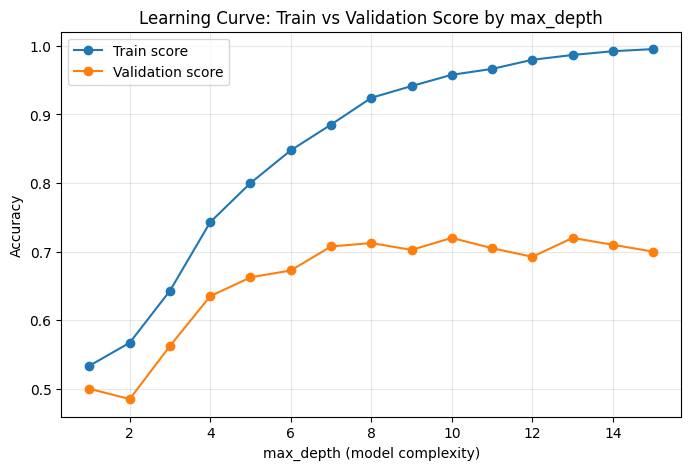

Best max_depth by validation score: 10


In [3]:
depth_range = range(1, 16)
train_scores_mean = []
val_scores_mean = []

for depth in depth_range:
    tree = DecisionTreeClassifier(max_depth=depth, random_state=42)
    train_sizes, train_scores, val_scores = learning_curve(
        tree, X, y, cv=5, train_sizes=[0.8], random_state=42
    )
    train_scores_mean.append(train_scores.mean())
    val_scores_mean.append(val_scores.mean())

plt.figure(figsize=(8, 5))
plt.plot(list(depth_range), train_scores_mean, marker="o", label="Train score")
plt.plot(list(depth_range), val_scores_mean, marker="o", label="Validation score")
plt.xlabel("max_depth (model complexity)")
plt.ylabel("Accuracy")
plt.title("Learning Curve: Train vs Validation Score by max_depth")
plt.legend()
plt.grid(alpha=0.3)
plt.show()

best_depth = list(depth_range)[int(np.argmax(val_scores_mean))]
print("Best max_depth by validation score:", best_depth)


## Practice Exercise

Try it yourself:

1. Change `test_size` in `train_test_split` to `0.4` and re-run Example 1 — does the overfit gap get bigger or smaller?
2. Add a 4th feature, `tackles_won`, with random noise (no real signal). Does the overfit tree's train accuracy go up? Why?

In [4]:
# Your code here




## Mini Challenge

Using the `best_depth` found above, apply **Fix 2 (regularization)** instead: train a tree with `max_depth=None` but with `ccp_alpha=0.02` (cost-complexity pruning). Compare its train/test accuracy to both the overfit tree and the `best_depth` tree. Which fix generalizes better here?

In [5]:
# Fix 2: regularization via cost-complexity pruning
pruned_tree = DecisionTreeClassifier(max_depth=None, ccp_alpha=0.02, random_state=42)
pruned_tree.fit(X_train, y_train)
print("Pruned tree (ccp_alpha=0.02)")
print("Train accuracy:", round(pruned_tree.score(X_train, y_train), 3))
print("Test accuracy: ", round(pruned_tree.score(X_test, y_test), 3))


Pruned tree (ccp_alpha=0.02)
Train accuracy: 0.843
Test accuracy:  0.9


## Summary

- Underfitting = high error everywhere. Overfitting = low train error, high test error.
- Learning curves made the train/validation gap visible instead of theoretical.
- Three fixes exist for overfitting — today I applied simpler depth (Fix: simpler model) and cost-complexity pruning (Fix: regularization) and compared results.
- Next: turning this into a reusable diagnostic step before trusting any model's accuracy score.